#Utility functions

In [ ]:
def check(p,alpha):
  print('p = ',p)
  print('alpha = ',alpha,'\n')
  if p<=alpha:
    print('p <= alpha\n')
    print("Ho - reject\nHa - accept")
  else:
    print('p > alpha\n')
    print("Fail to reject Ho\n")

#Assumptions in all tests


---

https://chatgpt.com/share/68dba06e-0ef4-8010-93c4-29bc573766ff



---

| Test                | Data Type                              | Key Use Case                               | Assumptions                                                                                                                                                                                |
| ------------------- | -------------------------------------- | ------------------------------------------ | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **Z-test**          | Continuous (numeric)                   | Mean/proportion when **σ known** or n ≥ 30 | • Random sampling  <br> • Independent observations  <br> • Population approx. normal (if n small)  <br> • Population **σ known**                                                           |
| **T-test**          | Continuous (numeric)                   | Mean comparison when **σ unknown**         | • Random sampling  <br> • Independent observations  <br> • Normality of population (important if n small)  <br> • Variances equal (for independent samples t-test, unless Welch’s is used) |
| **Chi-square (χ²)** | Categorical (counts)                   | Goodness of fit, independence, homogeneity | • Random sampling  <br> • Independent observations  <br> • Expected frequency ≥ 5 in ≥ 80% cells (none < 1)  <br> • Categories mutually exclusive                                          |
| **ANOVA**           | Continuous outcome, categorical groups | Comparing means of ≥ 3 groups              | • Random sampling  <br> • Independent observations  <br> • Normality of residuals in each group  <br> • Homogeneity of variances (equal across groups)                                     |



#Hypothesis Framework


---

Hypothesis testing is a statistical method used to make decisions or inferences about a population based on sample data.

You start with two competing statements:

Null Hypothesis (H₀) — the default or existing belief (no effect, no difference).

Alternative Hypothesis (H₁ or Ha) — what you want to test or prove (some effect, some difference).

---

[ChatGPT Explanation](https://chatgpt.com/share/68da21fb-9164-8010-bca1-351fd80606ce)



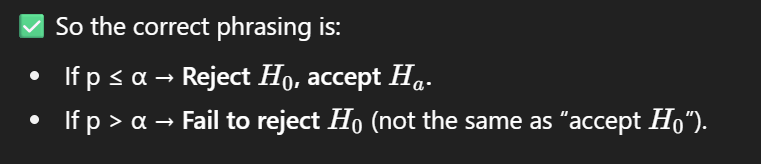

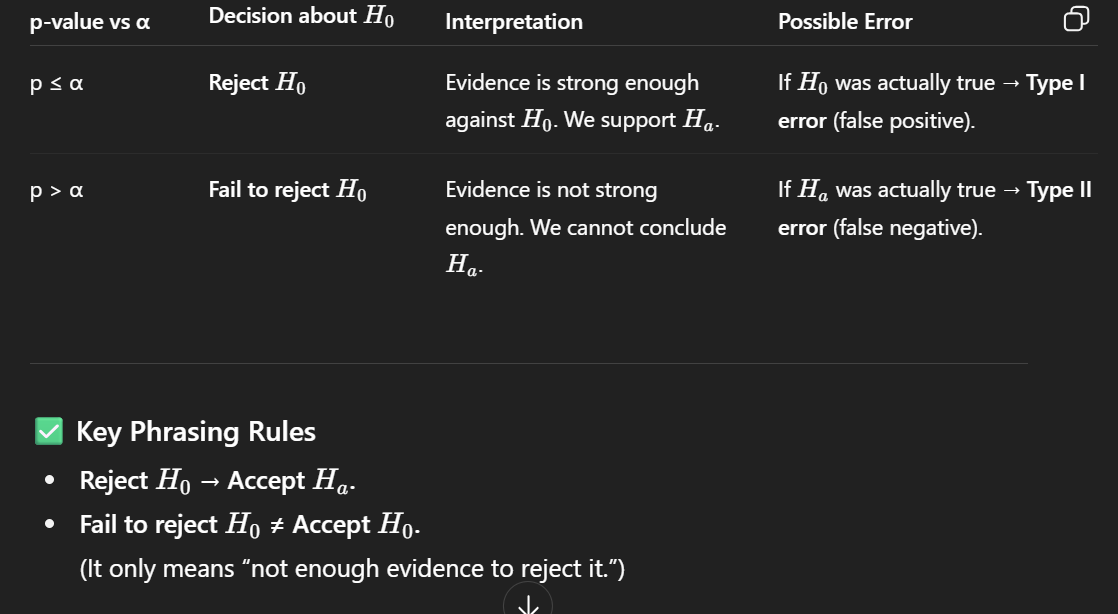

# One Sample Z-test/Z-statistic/Test Statistic


---
**Z-test**

Data type: Continuous, approx. normally distributed.

Sample size: Large (n ≥ 30) OR population variance known.

**Assumptions:**

- Random sampling.

- Independent observations.

- Population is normal (for small n).

- Population standard deviation (σ) is known.

---



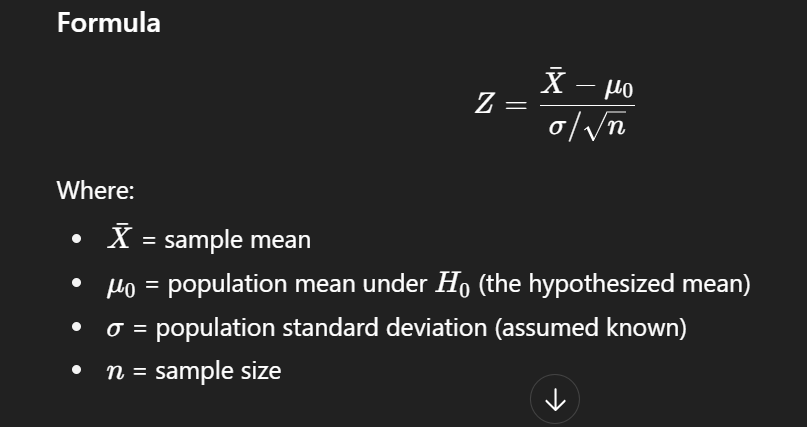


      If σ is unknown, you cannot use the Z-test; you use a t-test instead.


left tailed(Ha:sample_mean < population_mean): `p=norm.cdf(z)`

right tailed(Ha:sample_mean > population_mean): `p=1-norm.cdf(z)`

two tailed(Ha:sample_mean != population_mean): `p=2 * (1 - norm.cdf(abs(z)))` or `2 * min(norm.cdf(z), 1 - norm.cdf(z))`



---
<br>



#Z-test(one sample)



---

`from statsmodels.stats.weightstats import ztest`

`z,p=ztest(x,value=pop_mean,alternative=)`

x : sample_set



##Z-test (One sample) if sample stats given


---


`z, p = ztest_1samp_from_stats(sample_mean, pop_mean, pop_std, n, alternative="two-sided")`

In [ ]:
from scipy.stats import norm
from statsmodels.stats.power import zt_ind_solve_power

def ztest_1samp_from_stats(sample_mean, pop_mean, pop_std, n, alpha=0.05, alternative="two-sided"):
    """
    Perform a one-sample Z-test from summary statistics.

    Parameters:
        sample_mean : float
            Mean of the sample.
        pop_mean : float
            Population mean under the null hypothesis.
        pop_std : float
            Population standard deviation.
        n : int
            Sample size.
        alpha : float, default=0.05
            Significance level.
        alternative : str, default='two-sided'
            Type of test: 'two-sided', 'greater', or 'less'.

    Returns:
        dict :
            Dictionary containing:
            - z_stat : Z-statistic
            - p_value : P-value of the test
            - z_critical : Critical Z value
            - x_critical : Critical value(s) in original units
            - power : Statistical power
            - decision : 'Reject H0' or 'Fail to reject H0'
    """

    alt = alternative.lower()
    if alt not in ["two-sided", "greater", "less"]:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    SE = pop_std / (n ** 0.5)
    z_stat = (sample_mean - pop_mean) / SE

    if alt == "two-sided":
        z_critical = norm.ppf(1 - alpha/2)
        x_critical = (pop_mean - z_critical*SE, pop_mean + z_critical*SE)
        p_value = 2 * (1 - norm.cdf(abs(z_stat)))
        decision = "Reject H0" if abs(z_stat) > z_critical else "Fail to reject H0"
        alt_power = "two-sided"
    elif alt == "greater":
        z_critical = norm.ppf(1 - alpha)
        x_critical = pop_mean + z_critical*SE
        p_value = 1 - norm.cdf(z_stat)
        decision = "Reject H0" if z_stat > z_critical else "Fail to reject H0"
        alt_power = "larger"
    else:  # 'less'
        z_critical = norm.ppf(alpha)
        x_critical = pop_mean + z_critical*SE
        p_value = norm.cdf(z_stat)
        decision = "Reject H0" if z_stat < z_critical else "Fail to reject H0"
        alt_power = "smaller"

    effect_size = (sample_mean - pop_mean) / pop_std
    power = zt_ind_solve_power(effect_size=effect_size, nobs1=n, alpha=alpha, alternative=alt_power)

    print("z_stat : ", z_stat)
    print("p_value : ", p_value)
    print("z_critical : ", z_critical)
    print("x_critical : ", x_critical)
    print("power : ", power)
    print("decision : ", decision)


# Critical Value:



---

`CL = 1 - alpha`

`alpha = 1- CL`


# Left-tailed


`z_left = norm.ppf(alpha)`

# Right-tailed


`z_right = norm.ppf(1 - alpha)`

# Two-tailed


`z_two = norm.ppf(1 - alpha/2)`

##CODE

In [ ]:
from scipy.stats import norm

def critical_value(pop_mean, pop_std, cl=0.95, alternative="two-sided"):
    alpha = 1 - cl
    alt = alternative.lower()

    if alt == "two-sided":
        z_critical = norm.ppf(1 - alpha/2)
        x_critical = (pop_mean - z_critical*pop_std, pop_mean + z_critical*pop_std)
    elif alt == "greater":
        z_critical = norm.ppf(1 - alpha)
        x_critical = pop_mean + z_critical*pop_std
    else:  # 'less'
        z_critical = norm.ppf(alpha)
        x_critical = pop_mean + z_critical*pop_std

    print("x_critical : ", x_critical)
    print("z_critical : ", z_critical)


`z_critical, x_critical, p_critical = ztest_critical_values(pop_mean=, pop_std=, n=, confidence=, alternative="")`

In [ ]:
from scipy.stats import norm
import math

def ztest_critical_values(pop_mean, pop_std, n, confidence=0.95, alternative="two-sided"):
    alpha = 1 - confidence
    se = pop_std / math.sqrt(n)

    if alternative == "two-sided":
        z_crit = norm.ppf(1 - alpha/2)
        x_lower = pop_mean - z_crit * se
        x_upper = pop_mean + z_crit * se
        return {
            "Z_critical": (-z_crit, z_crit),
            "X_critical": (x_lower, x_upper),
            "P_critical": alpha
        }
    elif alternative == "greater":
        z_crit = norm.ppf(1 - alpha)
        x_crit = pop_mean + z_crit * se
        return {
            "Z_critical": z_crit,
            "X_critical": x_crit,
            "P_critical": alpha
        }
    elif alternative == "less":
        z_crit = norm.ppf(alpha)
        x_crit = pop_mean + z_crit * se
        return {
            "Z_critical": z_crit,
            "X_critical": x_crit,
            "P_critical": alpha
        }
    else:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")


In [ ]:
ztest_critical_values(pop_mean=1800, pop_std=100, n=50, confidence=0.99, alternative="greater")

{'Z_critical': np.float64(2.3263478740408408),
 'X_critical': np.float64(1832.8995271426638),
 'P_critical': 0.010000000000000009}

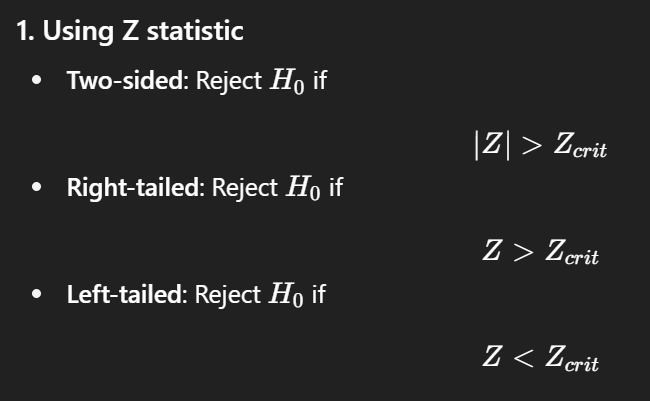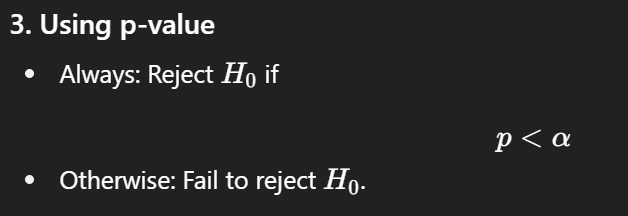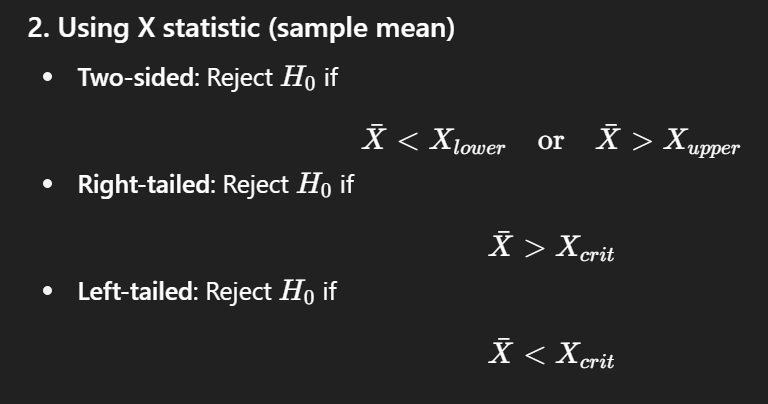

#Confidence Interval


---

`CI = Sample Mean ± (Z * (σ / √n))`


# Effect Size or Cohen's d


---

##For one-sample test
`d = (Sample Mean − Population Mean)/Sample Standard Deviation`

#Link
https://chatgpt.com/c/68d3b00c-c8ec-8322-97f9-5a3ed6839c2a

#Power of Test

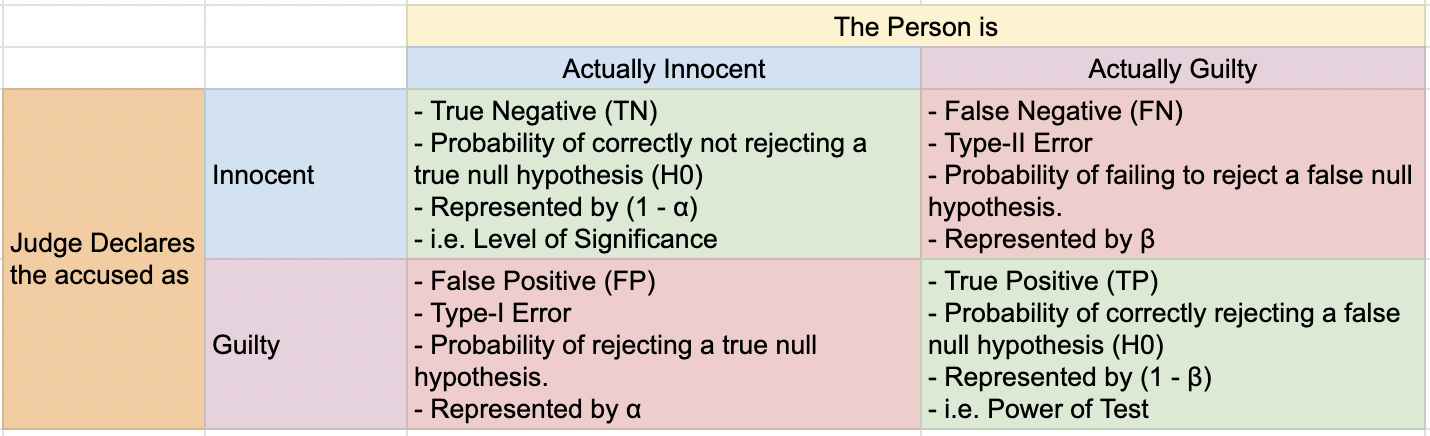
---

        ↑ Sample Size (n)          → ↑ Power
        ↑ Significance Level (α)   → ↑ Power
        ↑ Effect Size (δ)          → ↑ Power
        ↑ Measurement Precision    → ↑ Power
        ↑ Population Variability (σ) → ↓ Power


`from statsmodels.stats import power`

      power = power.zt_ind_solve_power(effect_size=effect_size,
                                 nobs1=sample_size,
                                 alpha=alpha,
                                 ratio=0,
                                 alternative='two-sided')

#Z-test (Two sample)


---

Z = $\frac{(\bar{x}_1 - \bar{x}_2)  -
 (μ_1 - μ_2)}{\sqrt{\frac{σ_1^2}{n_1} + \frac{σ_2^2}{n_2}}}$
  - Z: The z-score, a standard normal variable used to determine the probability of the observed difference between the two samples.
  - $\bar{x}_1$: The sample mean of the first sample.
  - $\bar{x}_2$: The sample mean of the second sample.
  - σ₁: The standard deviation of the first population.
  - σ₂: The standard deviation of the second population.
  - n₁: The size of the first sample.
  - n₂: The size of the second sample.
  - $μ_1$: Mean of the first population
  - $μ_2$: Mean of the second population
    - $μ_1 - μ_2 = 0$, represents the null hypothesis, which is the  assumption that there is no difference between the average values (means) of the two populations we're comparing.


#Z-test(Two samples)


---


`from statsmodel.stats.weightstats import ztest`

`z,p=ztest(x1=,x2=,value=0,alternative=)`

x1: sample_1

x2 : sample_2

value : pop_mean1 - pop_mean2 here 0


##If samples stats given

In [ ]:
from scipy.stats import norm
from statsmodels.stats.power import zt_ind_solve_power

def ztest_2samp_from_stats(mean1, mean2, std1, std2, n1, n2=None, alpha=0.05, alternative="two-sided"):
    """
    Perform a two-sample Z-test from summary statistics.

    Parameters:
        mean1, mean2 : float
            Sample means of group 1 and group 2.
        std1, std2 : float
            Population standard deviations of group 1 and group 2.
        n1 : int
            Sample size of group 1.
        n2 : int, optional
            Sample size of group 2. If None, assumed equal to n1.
        alpha : float, default=0.05
            Significance level.
        alternative : str, default='two-sided'
            Type of test: 'two-sided', 'greater', or 'less'.

    Returns:
        dict :
            Dictionary containing:
            - z_stat : Z-statistic
            - p_value : P-value of the test
            - z_critical : Critical Z value
            - x_critical : Critical value(s) in original units
            - power : Statistical power
            - decision : 'Reject H0' or 'Fail to reject H0'
    """

    alt = alternative.lower()
    if alt not in ["two-sided", "greater", "less"]:
        raise ValueError("alternative must be 'two-sided', 'greater', or 'less'")

    if n2 is None:
        n2 = n1

    SE = (std1**2 / n1 + std2**2 / n2) ** 0.5
    z_stat = (mean2 - mean1) / SE

    if alt == "two-sided":
        z_critical = norm.ppf(1 - alpha/2)
        x_critical = (mean1 - z_critical*SE, mean1 + z_critical*SE)
        p_value = 2 * (1 - norm.cdf(abs(z_stat)))
        decision = "Reject H0" if abs(z_stat) > z_critical else "Fail to reject H0"
        alt_power = "two-sided"
    elif alt == "greater":
        z_critical = norm.ppf(1 - alpha)
        x_critical = mean1 + z_critical*SE
        p_value = 1 - norm.cdf(z_stat)
        decision = "Reject H0" if z_stat > z_critical else "Fail to reject H0"
        alt_power = "larger"
    else:  # 'less'
        z_critical = norm.ppf(alpha)
        x_critical = mean1 + z_critical*SE
        p_value = norm.cdf(z_stat)
        decision = "Reject H0" if z_stat < z_critical else "Fail to reject H0"
        alt_power = "smaller"

    ratio = n2 / n1
    pooled_std = (std1 + std2)/2
    effect_size = (mean2 - mean1) / pooled_std
    power = zt_ind_solve_power(effect_size=effect_size, nobs1=n1,
                               alpha=alpha, alternative=alt_power, ratio=ratio)

    print("z_stat : ", z_stat)
    print("p_value : ", p_value)
    print("z_critical : ", z_critical)
    print("x_critical : ", x_critical)
    print("power : ", power)
    print("decision : ", decision)


#Z-proportion test (One sample)


---
- `from statsmodels.stats.proportion import proportions_ztest`

- `z,p=proportions_ztest(count=,nobs=,value=,alternative, prop_var=)`

  - count - no. of success in sample

  - nobs - sample size or no. of observations

  - value - proportion(fraction) in null hypothesis

  - prop_var - pass same as value

  - alternative -

                - "two-sided" for two tailed

                - "larger" for right tailed

                - "smaller" for left tailed


https://colab.research.google.com/drive/11ycbguuOrn7vAQZHraJnd--UPdXnGnUh#scrollTo=8bVmFNkWBSMP&line=16&uniqifier=1

#Z-proportion test (Two sample)


---


`z,p=proportions_ztest(count=count, nobs=nobs, alternative=)`

count - array of success in two samples

nobs - array of smaple sizes

#T-Test


---

**T-test (one-sample, independent, paired)**

Data type: Continuous.

Sample size: Small or large (works even when n < 30).

**Assumptions:**

- Random sampling.

- Independent observations (except paired t-test → dependence allowed within pairs).

- Approximately normal population (more critical for small n).

- Population variance unknown (estimated from sample).

- For independent samples t-test:

  - Equal variances (if using Student’s t-test).

  - If variances unequal → use Welch’s t-test.

#T-test(One sample)


---


`from scipy.stats import ttest_1samp`

`t,p = ttest_1samp(sample,population_mean,alternative="")`

        default alternative(if not passed) : 'two-sided'
        'two-sided' for two tailed
        'less' and 'greater' for one tailed test(left and right respectively)



#T-test(two sample/independent)


---
`from scipy.stats import ttest_ind`

`t_stat, pvalue = ttest_ind(sample_1, sample_2)`

        default alternative(if not passed) : 'two-sided'
        'two-sided' for two tailed
        'less' and 'greater' for one tailed test(left and right respectively)


        equal_var : True for equal variance(Default)
                  False for variance not equal


##If samples stats given

`from scipy.stats import ttest_ind_from_stats`

`t_stat, p_two = ttest_ind_from_stats(
   mean1=,
   std1=,
   nobs1=,
   mean2=,
   std2=,
   nobs2=,
   equal_var=True)`

      equal_var : True for equal variance(Default)
                  False for variance not equal

It doesn't have "alternative" keyword, thats why only give p_val of two-tailed

`p_right = p_two / 2 if t_stat > 0 else 1 - (p_two / 2)`

`p_left = p_two / 2 if t_stat < 0 else 1 - (p_two / 2)`

#Paired T-test


---

`from scipy.stats import ttest_rel`

`t_stat, p_value = ttest_rel(sample_before, sample_after, alternative='')`




        default alternative(if not passed) : 'two-sided'

        # 'two-sided' for two tailed

        # Left-tailed test (before < after) : 'less'

        # Right-tailed test (before > after) : 'greater'



#Chi-squared Test


---


**Chi-square (χ²) tests (Goodness of fit, Independence, Homogeneity)**

Data type: Categorical (counts/frequencies).

**Assumptions:**

- Random sampling.

- Independent observations.

- Expected cell frequency ≥ 5 (rule of thumb; at least 80% of cells should satisfy this, none < 1).

- Categories are mutually exclusive.



---


- Statistical test (chistat, pvalue)


`from scipy.stats import chisquare`

- for pdf,cdf and contigency table

`from scipy.stats import chi2, chi2_contingency`


<br>

Ho :  meets expectations


Ha :  don't meet expectations

`chi_stat, p_value = chisquare(
    observed_array,
    expected_array
)`

      observed_array : Observed or actual
      expected_array : Expected


##for independent chi-sq test where only observed is given


Ho :  independent OR not associated


Ha :  not independent OR associated

`chi_stat, p_value, dof, expected_data = chi2_contingency(observed_data)`

#ANOVA TEST(F-ratio/F-stat)


---


**ANOVA (Analysis of Variance)**

Data type: Continuous outcome, categorical groups.

Assumptions:

- Random sampling.

- Independent observations.

- Normal distribution of residuals in each group.

- Homogeneity of variances (equal variance across groups → testable by Levene’s or Bartlett’s test).

- Groups are independent.


---


#One Way ANOVA

- **Null hypothesis($H_0$):** States that the means of all groups are equal.
- **Alternate hypothesis($H_1$):**  States that at least one of the means is different.


`from scipy.stats import f_oneway`

`f_stats, p_value = f_oneway(sample_1, sample_2, sample_3, etc.)`

#Kruskal-Wallis Test
---
The Kruskal-Wallis test is a statistical test used to compare the medians of two or more independent groups.

It is an alternative to the one-way ANOVA, making it useful when data is not normally distributed.

**Null Hypothesis (H0):**

* The populations of all groups have the same median.
  * In other words, there is no statistically significant difference in the medians of the groups being compared.

**Alternative Hypothesis (H1):**

* At least one of the populations has a different median.
  * There is a statistically significant difference in the medians of at least two groups.

<br>

**Advantages of Kruskal-Wallis Test:**

- No assumption of normality:
    It doesn't require the data to be normally distributed.
- Robust to outliers:
    Outliers don't significantly affect the results.

<br>

**Limitations of Kruskal-Wallis Test:**

- Doesn't provide information about which groups differ: It only tells you if there is a difference, not which groups specifically differ.
- Less powerful than ANOVA when assumptions are met: If the data is normally distributed and has no outliers, ANOVA is more powerful.

`from scipy.stats import kruskal`

`stat, p_value = kruskal(sample_1, sample_2, sample_3, etc.)`

#Normality-Test

##QQ-plot

```
import matplotlib.pyplot as plt

from statsmodels.graphics.gofplots import qqplot
qqplot(dataset,line="s")
plt.show()

```


##Shapiro-Wilk test

Ho : Gaussian or Normal Dist.

Ha : Not Normal Dist.

- If **p <= alpha** : reject Ho, accept Ha

- If **p > alpha** : Fail to reject Ho


`from scipy.stats import shapiro`

`stat, p_value = shapiro(sample)`

#Variability (spread) Test

##Levene Test

Ho : Variances are relatively equal across the groups

Ha : Variances significantly differ across the groups

- If **p <= alpha** : reject Ho, accept Ha

- If **p > alpha** : Fail to reject Ho


`from scipy.stats import levene`

`levene_stat, p_value = levene(sample_1, sample_2, etc.)`

#Two-Way ANOVA Test

##Assumptions:

  - Gaussian distribution



> **What should be the null and alternate hypothesis?**

1. <font color='green'>Null Hypotheses for Main Effects:</font>
   - **Null Hypothesis for Flavor:** There is no significant difference in *dependent column* between the *independent column*
   - etc.

2. <font color='green'>Alternative Hypotheses for Main Effects:</font>
   - **Alternative Hypothesis for Flavor:** There is a significant difference in *dependent column* between at least two category in *independent column*.
   - etc.

<br>

1. <font color='green'>Null Hypothesis for Interaction Effect:</font>
   - **Null Hypothesis for Interaction Effect:** There is no interaction effect between the *independent-col-1 and independent-col-2* on dependent-col. (i.e.,In other words, the impact of flavor on sales does not depend on the location, and vice versa.)

2. <font color='green'>Alternative Hypothesis for Interaction Effect:</font>
   - **Alternative Hypothesis for Interaction Effect:** There is a significant interaction effect between the *independent-col-1 and independent-col-2* on dependent-col. (i.e., In other words, the impact of flavour on sales depends on the location, or the impact of location on sales depends on the flavour.)




```

import statsmodels.api as sm
from statsmodels.formula.api import ols

```




In [ ]:
# perform two-way ANOVA

# fit an ols model on the dataframe
# use 'fit()' to fit the linear model
# ols('dependent variable ~ C(independent variable1) * (independent variable2)', data=df).fit()
# ~ : This symbol separates the dependent variable from the independent variables and their interactions.
# C(): This indicates that the variable following it is treated as a categorical variable.
# the + sign is used to - main effect
# the : sign is used to - interaction effect
# the * sign is used to - both

test = ols('Sales ~ C(Flavour) * C(Location)', data=df).fit()

# create a table for a 2-way ANOVA test
# Pass the linear model 'test'
# 'typ = 2' performs two-way ANOVA
anova_table = sm.stats.anova_lm(test, typ = 2)

# Display the results
print(anova_table)

                               sum_sq    df         F    PR(>F)
C(Flavour)                6919.558981   2.0  1.968465  0.145773
C(Location)               2059.273884   3.0  0.390546  0.760092
C(Flavour):C(Location)   11802.257765   6.0  1.119163  0.357804
Residual                154669.016331  88.0       NaN       NaN


OR

```
import pingouin as pg
```

In [ ]:
model=pg.anova(dv='Sales',
                between=['Location','Flavour'],
                data=df,
                ss_type=2)

print(round(model,4))

               Source           SS    DF         MS       F   p-unc     np2
0            Location    2059.2739   3.0   686.4246  0.3905  0.7601  0.0131
1             Flavour    6919.5590   2.0  3459.7795  1.9685  0.1458  0.0428
2  Location * Flavour   11802.2578   6.0  1967.0430  1.1192  0.3578  0.0709
3            Residual  154669.0163  88.0  1757.6025     NaN     NaN     NaN


#KS-Test(Kolmogorov-Smirnov Test)

##Assumptions

 - It's distribution-free, which means you can use it even when you're not sure about the underlying distribution of the data.
 - The KS-Test assesses the similarity of the entire distribution, not just the means.


 So, Two-Sample Z-Tests and the KS-Test serve different purposes:
- A Two-Sample Z-Test is handy when you want to compare means and make specific assumptions about the population.
- But the KS-Test is your go-to when you want to check if two datasets have the same distribution, even if you're uncertain about that distribution.



---


**Under the null hypothesis**, when X and Y follow the same distribution, the test statistic ($T_{ks}$) tends towards zero. This is because their CDFs overlap with each other.


In contrast, **under the alternative hypothesis**, when X and Y have different distributions, the test statistic ($T_{ks}$) is a very large positive value. This means there's a significant difference between the two CDFs, indicating that the distributions are not the same.



---
- the Kolmogorov distribution, you'll notice it has no negative values.
- The Kolmogorov-Smirnov Test is a Right-tailed test


- Null Hypothesis ($H_o$): The distribution of sample 1 is the same as the distribution of sample 2.

- Alternative Hypothesis ($H_a$): The distribution of sample 1 is different from the distribution of sample 2.

```
from scipy.stats import kstest

_ , p = kstest(sample-1, sample-2)
```

#Correlation

<font color='purple'>Let's recall our conceptual learnings in the hypothesis testing.</font>


- <font color='purple'>Numerical Vs Categorical (2 Categories):</font>
  - We use 2 samples T-test or Z-test.
  - It helps us see if there's a difference in the numerical values between these two categories.
- <font color='purple'>Numerical Vs Categorical (>2 Categories):</font>
 - We use the ANOVA test.
 - This test helps us figure out if there's a significant difference among the numerical values when we have more than two categories to compare.
- <font color='purple'>Categorical Vs Categorical:</font>
 - We use the Chi-square test.
 - It's like a detective tool that helps us find out if there's a relationship or connection between these categories.
- <font color='purple'>Numerical Vs Numerical:</font>
 - If these two variables are related, we use a correlation test.
 - It helps us figure out if changes in one variable are connected to changes in the other variable.



##Covariance

Covariance measures the direction and the strength of the linear relationship between two variables.

**General Formula:** $Cov(X, Y) = E[(X - E(X))(Y - E(Y))]$

Where:
- E represents the expected value (average).
- X and Y are the two variables (i.e., Height & Weight)
- E(X) and E(Y) represent the average values of X and Y, respectively.(E(X) represents $\bar{h}$ & E(Y) represents $\bar{w}$)

---

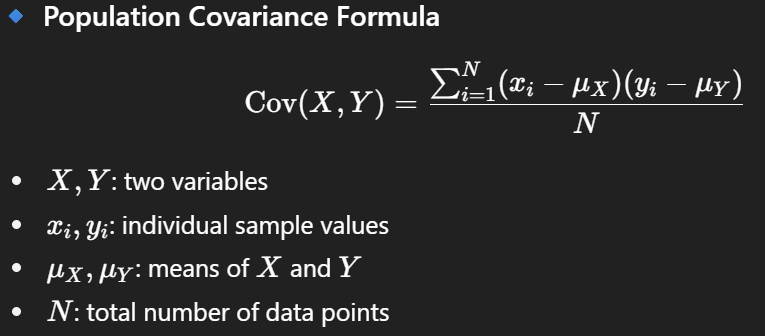
---
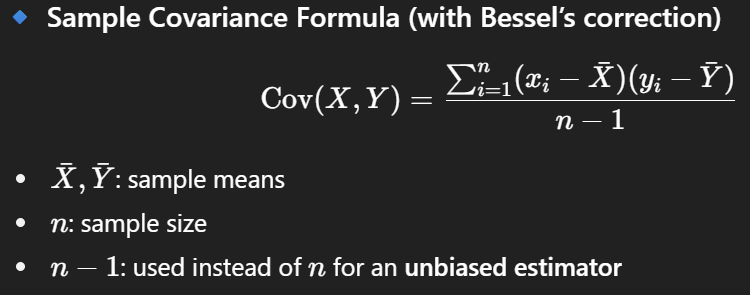
---
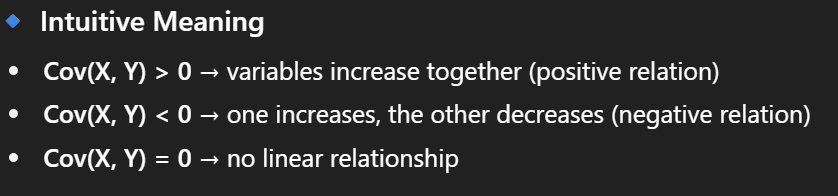
---



https://chatgpt.com/share/68e7540b-e408-8010-9f5c-b65c0c6c26cf

- Covariance captures the direction and strength of the relationship, but its units depend on the variables.
- Correlation removes the units and standardizes the relationship on a scale of -1 to 1, making it easier to compare relationships between different variables.

When using Correlation, we can compare measurements in a way that makes sense, irrespective of the units we're using.

Further, the correlation value always falls between **-1 and 1**.

This value, often called **rho**, is the correlation coefficient.
  - It tells us how strong and in which direction two things are related.
  - If it's positive, there's a direct connection (directly proportional).
  - If it's negative, there's an opposite relationship (indirectly proportional).

##Pearson Correlation

The formula for calculating Correlation:

 $Corr = \frac{Covariance(x, y)}{σ_x . σ_y}$

##Spearman Correlation

**Spearman Correlation** steps in to resolve the challenge posed by **non-linear relationships**.

Unlike Pearson correlation, Spearman correlation isn't confined to linear patterns.

It assesses relationships by considering the ranks of values, providing a more encompassing view of the data's behaviour.



| Feature               | Pearson            | Spearman              |
| --------------------- | ------------------ | --------------------- |
| Measures              | Linear correlation | Monotonic correlation |
| Based on              | Actual values      | Ranks                 |
| Sensitive to outliers | Yes                | Less                  |
| Data type             | Interval/Ratio     | Ordinal/Interval      |
| Detects nonlinearity  | No                 | Yes (if monotonic)    |


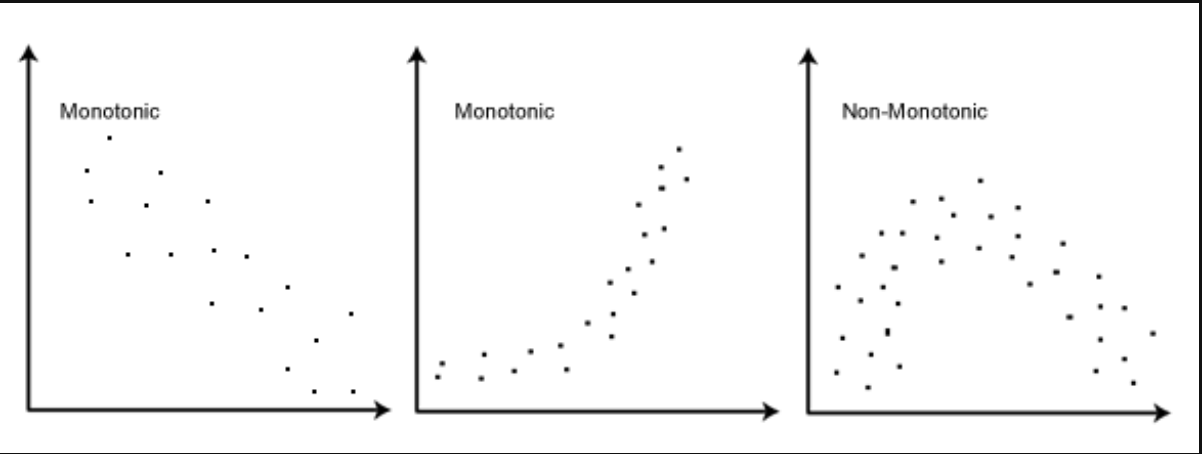

`from scipy.stats import pearsonr, spearmanr`

**Correlation Test:**
- Type: Parametric (Pearson), non-parametric (Spearman)
- Reason: Pearson assumes bivariate normal distribution, while Spearman does not make any distributional assumptions.

**Pearson Correlation:**
- Type: Parametric
- Reason: Assumes bivariate normal distribution.

**Spearman Correlation:**
- Type: Non-parametric
- Reason: Does not make distributional assumptions and is based on the ranking of values.

> **Q. What is meant by a Bivariate Normal Distribution?**

Suppose there are two random variables X and Y that both follow the **Normal distribution**.

Suppose you take any real numbers `a` and `b`, and create a new random variable `Z` as a linear combination of `X` and `Y`, i.e., $Z=aX+bY$

If the resulting random variable `Z` (given by the **linear combination**), is also normally distributed, we say that `X` and `Y` follow  **Bivariate Normal Distribution**.

- It implies that not only are X and Y individually normally distributed, but any linear combination of X and Y (where the coefficients are real numbers) will also result in a random variable that follows a normal distribution.

- This property makes bivariate normal distributions mathematically convenient and allows for various statistical analyses and predictions.




<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/060/254/original/Screenshot_2023-12-27_at_7.11.52_PM.png?1703684528">

#Skewness

Skewness is a way to describe the shape of a data distribution or the pattern of how data points are spread out.

It's like looking at the way a hill slopes.

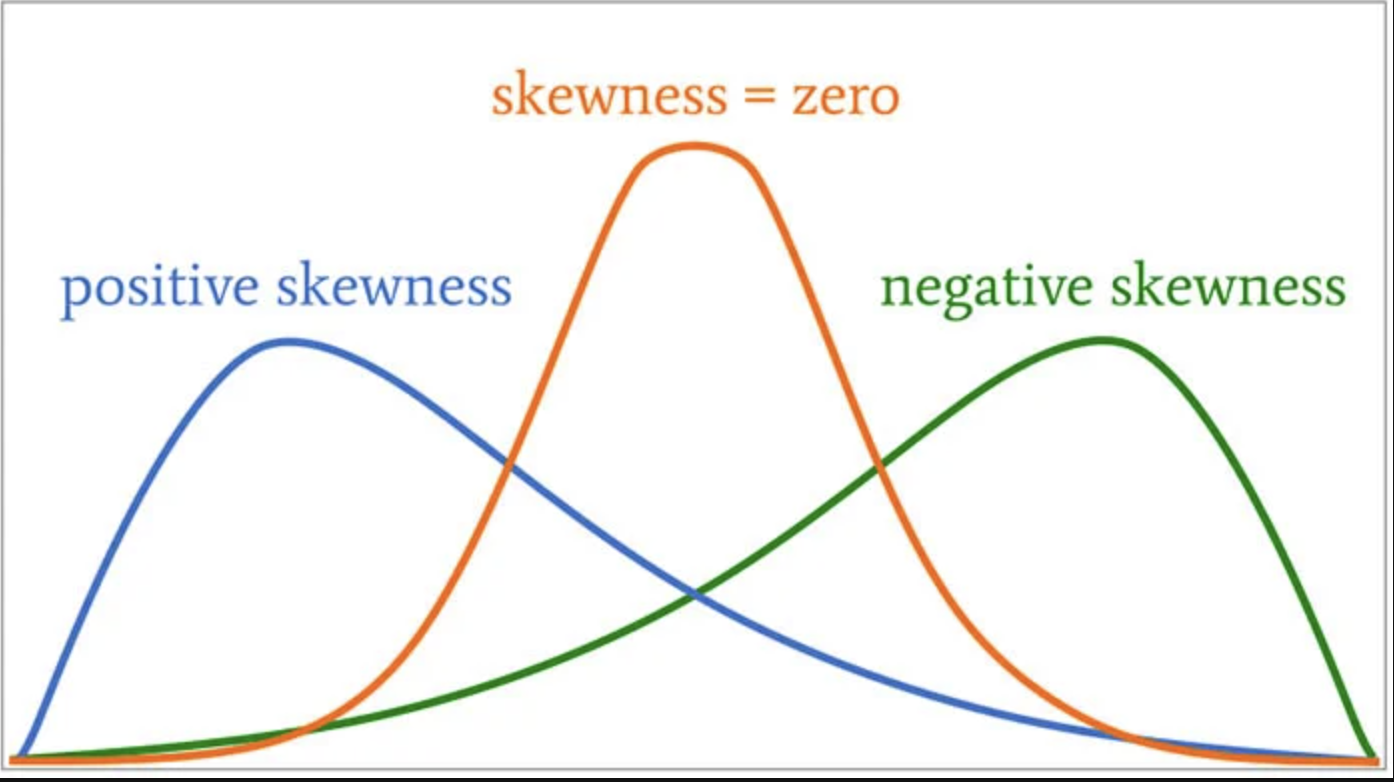

<font color='purple'>**What is Skewness**:</font>

- <font color='orange'>**Symmetrical Data (No Skewness)**:</font> If a distribution is perfectly balanced, with data evenly spread on both sides of the center, it's like a hill with equal slopes on both sides. We call this "symmetrical" or "no skewness."

- <font color='orange'>**Positive Skew (Right Skew)**:</font> When most of the data is on the left side (lower values) and a long tail extends to the right (higher values), it's like a hill that's steeper on the left and has a long, gentle slope on the right.

- <font color='orange'>**Negative Skew (Left Skew)**:</font> When most of the data is on the right side (higher values) and a long tail extends to the left (lower values), it's like a hill that's steeper on the right and has a long, gentle slope on the left.

<font color='purple'>**Why Skewness Matters**:</font>

Skewness is important because it helps us understand the data we're dealing with. It can tell us about things like:

- Where the "typical" or "average" value is.
- Whether there are extreme values far from the average.
- Whether the data tends to be more on one side or the other.

`df.skew()`

<img src="https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/014/655/original/skeness.jpg?1663009314" alt="skewness" width="600" height="250" />

| Skew Type | Skewness | Mean vs Median vs Mode | Notes              |
| --------- | -------- | ---------------------- | ------------------ |
| Symmetric | 0        | Mean = Median = Mode   | Perfectly balanced |
| Positive  | > 0      | Mode < Median < Mean   | Right tail longer  |
| Negative  | < 0      | Mean < Median < Mode   | Left tail longer   |


| **Skewness Value**      | **Shape / Interpretation** | **Meaning**                                                                |
| ----------------------- | -------------------------- | -------------------------------------------------------------------------- |
| **0**                   | Perfectly symmetric        | Mean = Median = Mode (e.g., Normal distribution)                           |
| **> 0 (Positive Skew)** | Right-skewed               | Tail on the right side is longer — more smaller values, few large outliers |
| **< 0 (Negative Skew)** | Left-skewed                | Tail on the left side is longer — more larger values, few small outliers   |


---


Typical interpretation guide:

  - |Skewness| < 0.5 → Fairly symmetric

  - 0.5 ≤ |Skewness| < 1 → Moderately skewed

  - |Skewness| ≥ 1 → Highly skewed

#Kurtosis

Kurtosis is a measure of how peaked or how heavily tailed the data is
- Peaked here means data is less spread out, and more concentrated around the Mean.

Skewness and kurtosis are both measures describes the shape of a distribution, but they focus on different aspects:
- Skewness focuses on the symmetry of the distribution, while kurtosis focuses on the concentration of data in the tails.
- Both measures provide valuable insights into the characteristics of a dataset.
- Both are helpful to see if data follows Normal Distribution or NOT.

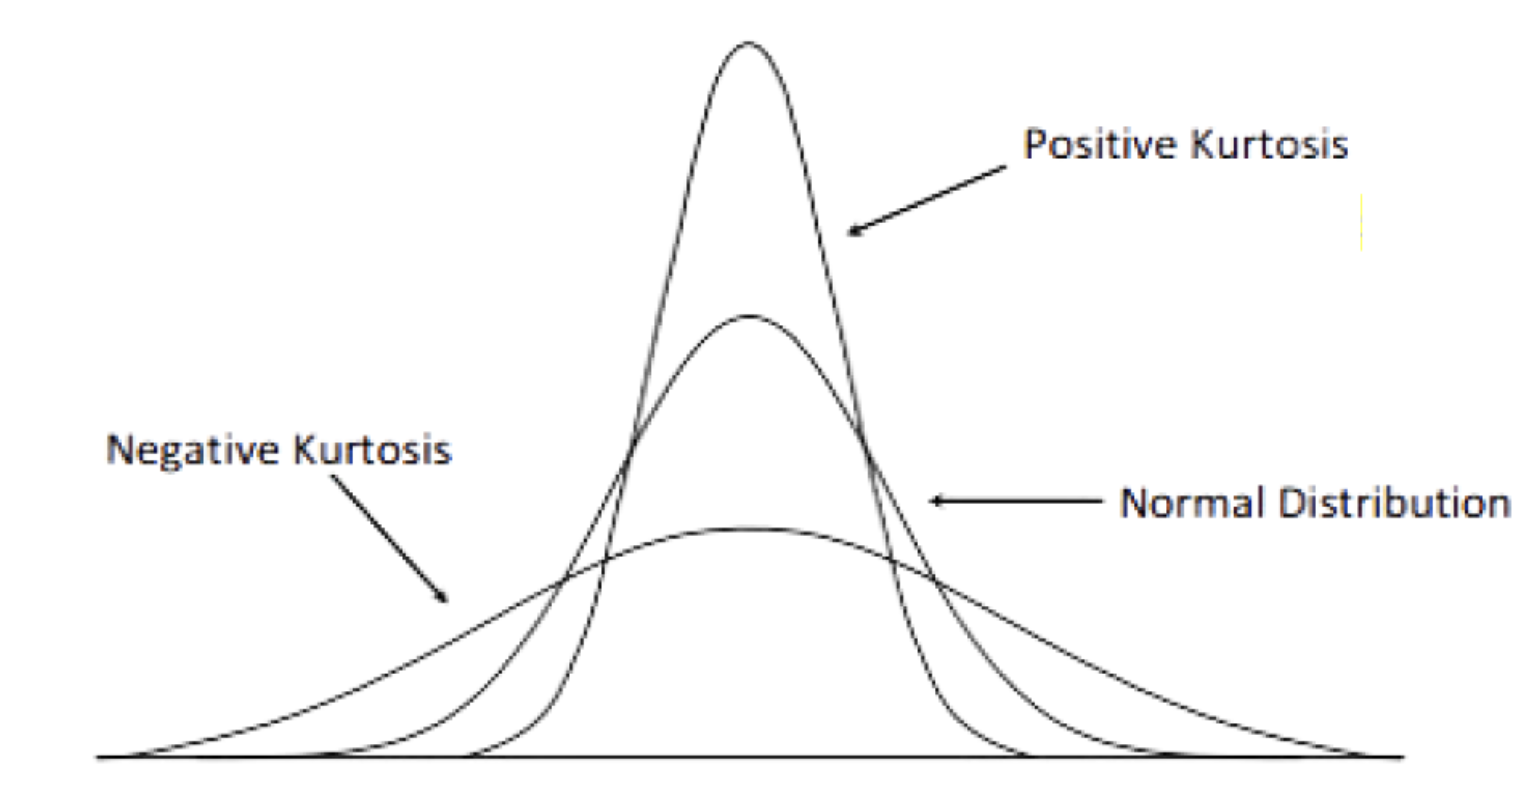

<font color='purple'>**What is Kurtosis:**</font>

Kurtosis is a way of figuring out how "pointy" or "flat" a graph of data is compared to a standard shape.

- <font color='orange'>**Leptokurtic (Pointy):**</font> If a graph is "leptokurtic," it means it's pointier in the middle with long sides. This happens when there are extreme values, making the data bunch up in the middle.

- <font color='orange'>**Mesokurtic (Normal):**</font> A "mesokurtic" graph is like a normal, balanced curve. It's not too pointy or too flat.

- <font color='orange'>**Platykurtic (Flat):**</font> If a graph is "platykurtic," it's flatter in the middle with a flattened peak. This occurs when the data is more spread out without many extreme values.


<font color='purple'>**Why Kurtosis Matters:**

Kurtosis helps us know if our data is normal or not. It helps in:

- **Detecting Outliers:** Spotting data points that are very different from the rest.  

- **Making Predictions:** Understanding if your data follows a typical pattern.

- **Making Decisions:** Knowing if extreme values should be given special attention in analysis.  


So, kurtosis is like a tool that tells us if our data is pointy (leptokurtic), normal (mesokurtic), or flat (platykurtic), giving us insights into the shape and behavior of our data.

`df.kurt()`

| **Excess Kurtosis Value** | **Type**        | **Interpretation**                                |
| ------------------------- | --------------- | ------------------------------------------------- |
| **0**                     | **Mesokurtic**  | Normal distribution (moderate tails, normal peak) |
| **> 0**                   | **Leptokurtic** | Heavy tails, sharper peak → more outliers         |
| **< 0**                   | **Platykurtic** | Light tails, flatter peak → fewer outliers        |


https://chatgpt.com/share/68e75c1d-80f8-8010-847c-705bf7e05e33